<br>

<div style="text-align: center">Confidential – Qualcomm Technologies, Inc. and/or its affiliated companies – May Contain Trade Secrets</div>

<div style="text-align: center; font-weight: bold">MAY CONTAIN U.S. AND INTERNATIONAL EXPORT CONTROLLED INFORMATION</div> <br>

**Takeaways:** Users will learn how to compile and execute The ResNet-50 neural network model on Qualcomm® Cloud AI (AIC) Inference Accelerator

**Before you start:** There are some commands (folder locations etc) that will need to be updated in this notebook based on your platform and installation location. Some commands might need sudo prefix to run properly.

**Last Verified Qualcomm Cloud AI 100 Platform SDK and Apps SDK Version:** 1.9.1.25 

## Qualcomm Cloud AI Getting started with ResNet-50

This notebook provides instructions for compiling and executing the ResNet-50 model on the Qualcomm® Cloud AI (AIC) Accelerator Card.  

The following topics are covered in this notebook:

**ResNet50 ONNX Example**
   > 1) Download the model
    > 2) Input pre-processing
    > 3) Compilation
    > 4) Inferencing
    > 5) Output post-processing
    > 6) End-to-End Latency


In [1]:
# Install python packages
!pip3 install -r requirements.txt

## ResNet-50 Example

In this example we will download a ResNet-50 model from ONNX model zoo, prepare input data, compile, execute and validate the results.

![Workflow](images/workflow.png "Workflow")

## Download ONNX Model
Download the following model and other assets:

* **resnet50-v1-7.onnx** Resnet-50 model in ONNX format <br>
* **cat_281_299.png** ImageNet test image<br>
* **imagenet_class_index.json** ImageNet class list <br>

In [14]:
!cat ./download_resnet50_model.sh

###############################################################################
#  Download the following model and other assets:
#    1) resnet50-v1-7.onnx: Resnet-50 model in ONNX format
#    2) cat_281_299.png: ImageNet test image
#    3) imagenet_class_index.json: ImageNet class list
###############################################################################

#!/bin/bash
# Remove if already exists.
if [ -e resnet50-v1-7.onnx ]; then
	rm -rf resnet50-v1-7.onnx
fi

if [ -e cat_281_299.png ]; then
	rm -rf cat_281_299.png
fi

if [ -e imagenet_class_index.json ]; then
	rm -rf imagenet_class_index.json
fi

# Download the following model and other assets
if [ ! -e resnet50-v1-7.onnx ]; then
    wget -c https://github.com/onnx/models/raw/main/vision/classification/resnet/model/resnet50-v1-7.onnx
fi

image=cat_281_299.png

if [ ! -e ${image} ]; then
    wget -c https://github.com/pytorch/glow/raw/master/tests/images/imagenet_299/${image}
fi

if [ ! -e imagenet_class_index.json ]; then
 

In [3]:
!bash ./download_resnet50_model.sh

--2023-05-31 22:11:32--  https://github.com/onnx/models/raw/main/vision/classification/resnet/model/resnet50-v1-7.onnx
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/onnx/models/main/vision/classification/resnet/model/resnet50-v1-7.onnx [following]
--2023-05-31 22:11:32--  https://media.githubusercontent.com/media/onnx/models/main/vision/classification/resnet/model/resnet50-v1-7.onnx
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 102583340 (98M) [application/octet-stream]
Saving to: ‘resnet50-v1-7.onnx’

resnet50-v1-7.onnx  100%[===================>]  97.83M  96.6MB/s    in 1.0

Let's have a look at the input image

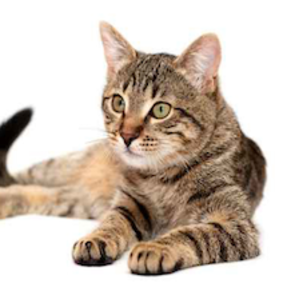

In [4]:
from IPython.display import Image
Image('cat_281_299.png')

## Input Pre-processing
Next we need to convert the test image to the tensor format expected by the ResNet-50 model. We'll use **input_pre-processing.py** script, which will handle this conversion.  It uses the OpenCV library and NumPy to normalize the RGB image data. Then we need the image data pre-processing for the mean subtraction.

In [15]:
!sudo python3 ./input_pre-processing.py

Pre-Processed data is created and saved as data.raw


## Compile the Network
The next step is to generate Cloud AI (AIC) network binaries from the ONNX model using the `qaic-exec` compiler.  The binaries are generated in the `compiler_output` folder. The network is compiled for 1 NSP compute core. 


In [6]:
!rm -rf ./compiler_output

!/opt/qti-aic/exec/qaic-exec \
    -m=./resnet50-v1-7.onnx \
    -onnx-define-symbol=N,1 \
    -convert-to-fp16 \
    -aic-hw \
    -aic-num-cores=1 \
    -compile-only \
    -aic-binary-dir=./compiler_output

Reading ONNX Model from ./resnet50-v1-7.onnx
loading compiler from: /opt/qti-aic/dev/lib/x86_64/libQAicCompiler.so
Compile started ............... 
Compiling model with FP16 precision.
Generated binary is present at ./compiler_output


## Inferencing
Run the compiled network binaries on AIC100 hardware with the `qaic-runner` tool.  The output layer is dumped to  `resnetv17_dense0_fwd__1-activation-0-inf-1.bin`.
```

In [30]:
!/opt/qti-aic/exec/qaic-runner \
    --test-data ./compiler_output/ \
    --input ./data.raw \
    --aic-num-of-activations 1 \
    --num-iter 1000 \
    --set-size 10 \
    --write-output-start-iter 1 \
    --write-output-num-samples 1 \
    --write-output-dir . \
    --aic-device-id 0

loading /opt/qti-aic/dev/lib/x86_64/libQAic.so
Input file: ./data.raw
Writing file:./resnetv17_dense0_fwd-activation-0-inf-1.bin
 ---- Stats ----
InferenceCnt 1000 TotalDuration 2287908us BatchSize 1 Inf/Sec 437.081


## Output Post-processing
For output post-processing, We'll use **output_post-processing.py** script, which has an imagenet helper and a class to parse the softmax results in resnetv17_dense0_fwd__1-activation-0-inf-1.bin then show the topk=5 results through Pandas.

Input cat image.

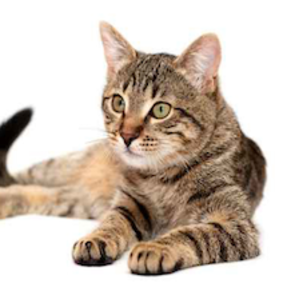

In [8]:
Image('cat_281_299.png')

In [9]:
!sudo python3 ./output_post-processing.py

Softmax dimensions: (1000,)
Top 5 matches:
  Top-K  Index           Class  Confidence
0    K1    281           tabby    0.730099
1    K2    285    Egyptian_cat    0.174774
2    K3    282       tiger_cat    0.093550
3    K4    287            lynx    0.001081
4    K5    761  remote_control    0.000068



The Onnx ResNet-50 model classified the image as a "tabby" with a confidence score of 73%.

### End-to-End Latency

Latency statistics are available from the `qaic-runner` tool with the following options:

```
Usage: qaic-runner [options]
  -S, --set-size <i>                 Set Size for inference loop execution, default:10, min:1
  -l, --live-reporting               Enable Live reporting periodic at 1 sec interval, default off
  -s, --stats                        Enable Live Profiling Stats reporting periodically at 1 sec interval
```

End-to-end latency is calculated as:<br>
**preProcTime + execTotalTime + postProcTime**

Set size of 1 **--set-size 1** is recommended for latency measurement.  

<img src="./images/latency_e2e.png" alt="Latency Breakdown" width = 800 />

In [25]:
# Collect latency stats output for <max_run> runs

max_run = 3
results = [None] * max_run

for idx in range(0, max_run):
    print('Run {}'.format(idx))
    results[idx] = !/opt/qti-aic/exec/qaic-runner \
    --test-data ./compiler_output/ \
    --input ./data.raw \
    --aic-num-of-activations 1 \
    --num-iter 1000 \
    --aic-device-id 0 \
    --set-size 1 \
    --live-reporting 1000 \
    --stats

Run 0
Run 1
Run 2


Define a helper class QAicLatencyStats to parse the latency stats.

In [31]:
# Define a helper class QAicLatencyStats to parse the latency stats.
import re
import pandas as pd

class QAicLatencyStats:
    def __init__(self):
        pass
    
    def load(self, results):
        measurement_map = {'preProcessingLatencyStats': 'pre_proc_us',
                           'execTotalTimeStats': 'exec_total_us',
                           'execKernelToCompletStats': 'exec_kernel_to_complete_us',
                           'postProcessingLatencyStats': 'post_proc_us'}

        columns = ['activation', 'num_samples', 'timestamp_ms', 'num_inf_completed', 'rate_inf_sec']
        data = {}
        for column in columns:
            data[column] = []

        # Add measurement columns
        for key,value in measurement_map.items():
            data[value] = []
        
        for result in results:
            match = re.match('Activation\[([0-9]+)\]', result)
            if match:
                activation = int(match.group(1))
                #print('activation {}'.format(activation))
                data['activation'].append(activation)

            match = re.match('NumSamples\:\s+([0-9]+)', result)
            if match:
                num_samples = int(match.group(1))
                #print('num_samples {}'.format(num_samples))
                data['num_samples'].append(num_samples)

            match = re.match('([\w]+) \(us\).+avg\:\s+([0-9\.]+)', result)
            if match:
                measurement = match.group(1)
                if measurement in measurement_map.keys():
                    measurement = measurement_map[measurement]
                    latency = float(match.group(2))
                    data[measurement].append(latency)

            match = re.match('timestamp\:\s+([0-9]+)ms\s+numInfCompleted\:\s+([0-9]+)\s+rate\:\s+([0-9\.]+) Inf\/Sec', result)
            if match:
                timestamp = int(match.group(1))
                num_inf_completed = int(match.group(2))
                rate_inf_sec = float(match.group(3))
                data['timestamp_ms'].append(timestamp)
                data['num_inf_completed'].append(num_inf_completed)
                data['rate_inf_sec'].append(rate_inf_sec)
                                
        df = pd.DataFrame.from_dict(data)
        df['e2e_total_latency_us'] = df['pre_proc_us'] + df['exec_total_us'] + df['post_proc_us']
        return df

Parse and show the average latency results.

In [32]:
#import QAicLatencyStats from get-latency-stat

latency_stats = QAicLatencyStats()

avg = 0
df = pd.DataFrame()
for idx in range(0, max_run):
    run_df = latency_stats.load(results[idx])
    avg += run_df['e2e_total_latency_us'].mean()
    run_df['run'] = idx
    df = pd.concat([run_df, df])

print('Average e2e latency: {:0.2f} us'.format(avg / max_run))

Average e2e latency: 2442.18 us


<div style="text-align: center">Confidential – Qualcomm Technologies, Inc. and/or its affiliated companies – May Contain Trade Secrets</div>

<div style="text-align: center; font-weight: bold">MAY CONTAIN U.S. AND INTERNATIONAL EXPORT CONTROLLED INFORMATION</div>